# COMP3008 Big Data Analytics — Assessment 2
## How has COVID-19 impacted employment patterns and regional economies in the UK?
**Data source:** UK Annual Population Survey (APS), January 2019 – December 2024  
**Module:** COMP3008 | University of Plymouth

---

### How this notebook is organised
| Section | Purpose | Report section it feeds |
|---|---|---|
| 1. Setup | Imports and paths | — |
| 2. Load & Merge | Read both CSVs, combine into one DataFrame | Pre-processing |
| 3. Pre-processing | Column harmonisation, type fixing, missingness | Pre-processing |
| 4. EDA — Method 1 | Descriptive statistics & distributions | Application of Methods |
| 5. EDA — Method 2 | Labour-status time-series trend (2019–2024) | Application of Methods |
| 6. EDA — Method 3 | Regional comparison (employment rate by Government Office Region) | Application of Methods |
| 7. EDA — Method 4 | K-Means clustering of worker profiles | Application of Methods |
| 8. Predictive — ARIMA | Time-series forecast of annual employment rate | Application of Methods |
| 9. Predictive — Ridge | Linear regression of gross weekly pay | Application of Methods |
| 10. Predictive — RF | Random Forest regression of gross weekly pay | Application of Methods |
| 11. Model Comparison | Metrics table and suitability commentary | Results |

> **AI declaration:** Sections of this code were drafted with assistance from GitHub Copilot and Claude (A7 — code generation for learning purposes). All code has been reviewed, understood, and adapted by the student.

---
## Section 1 — Setup
Install any missing packages and import everything the notebook needs.  
Run this cell first every time.

In [28]:
%pip install numpy pandas matplotlib seaborn scikit-learn pmdarima --quiet

# ── Standard library ──────────────────────────────────────────────────────────
import warnings
from pathlib import Path

# ── Data ──────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ── Machine learning ──────────────────────────────────────────────────────────
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# ── Time-series ───────────────────────────────────────────────────────────────
# pmdarima gives us auto_arima which selects the best ARIMA order automatically.
# Install with: pip install pmdarima
try:
    from pmdarima import auto_arima
    ARIMA_AVAILABLE = True
except ImportError:
    print("pmdarima not found. Run: pip install pmdarima")
    ARIMA_AVAILABLE = False

warnings.filterwarnings("ignore")   # suppress minor sklearn/statsmodels warnings
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 130    # legible at 100% zoom as required by brief

# ── Paths ─────────────────────────────────────────────────────────────────────
# All paths are relative to this notebook's location — no hard-coded drives.
NOTEBOOK_DIR = Path().resolve()                      # wherever the notebook lives
DATA_DIR     = NOTEBOOK_DIR / "Report_Data"          # both CSVs sit here
OUT_DIR      = NOTEBOOK_DIR / "analysis_outputs"     # figures and CSVs written here
FIG_DIR      = OUT_DIR / "figures"                   # all saved figures

OUT_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

FILE_A = DATA_DIR / "AnnualPopulationSurvey_Jan2019_Dec2021.csv"
FILE_B = DATA_DIR / "AnnualPopulationSurvey_Jan2022_Dec2024.csv"

print("Setup complete.")
print(f"Data directory : {DATA_DIR}")
print(f"Output directory: {OUT_DIR}")

Note: you may need to restart the kernel to use updated packages.
Setup complete.
Data directory : X:\COMP3008 Report\Report_Data
Output directory: X:\COMP3008 Report\analysis_outputs


---
## Section 2 — Load & Merge

The APS is split across two files at a period boundary (2019–2021 and 2022–2024).  
Both must be combined into a single DataFrame for longitudinal analysis.  
Column names differ in case and suffix between files (e.g. `GOR9D` vs `GOR9DCENSUS2021`),  
so we normalise everything to **UPPER CASE** before merging.

> **Report link → Pre-processing section:** Describe the merge strategy and the reason for upper-casing here.

In [29]:
def load_csv(path: Path, period_label: str) -> pd.DataFrame:
    """Read one APS CSV, normalise column names, tag with source period."""
    df = pd.read_csv(path, low_memory=False)
    df.columns = df.columns.str.upper()   # standardise case across both files
    df["SOURCE_PERIOD"] = period_label    # lets us split back later if needed
    return df

df_a = load_csv(FILE_A, "2019-2021")
df_b = load_csv(FILE_B, "2022-2024")

print(f"File A shape: {df_a.shape}  ({df_a.shape[0]:,} rows, {df_a.shape[1]} columns)")
print(f"File B shape: {df_b.shape}  ({df_b.shape[0]:,} rows, {df_b.shape[1]} columns)")

# Concatenate vertically — columns that don't exist in one file become NaN.
raw = pd.concat([df_a, df_b], ignore_index=True, sort=False)
print(f"\nCombined shape: {raw.shape}  ({raw.shape[0]:,} rows, {raw.shape[1]} columns)")

File A shape: (430347, 527)  (430,347 rows, 527 columns)
File B shape: (320589, 474)  (320,589 rows, 474 columns)

Combined shape: (750936, 551)  (750,936 rows, 551 columns)


---
## Section 3 — Pre-processing

### 3a — Column harmonisation

Between 2019–2021 and 2022–2024 the ONS renamed several geographic fields  
to incorporate the 2021 Census geography. We coalesce renamed pairs into  
single canonical columns so downstream code has one consistent name to use.

| Canonical name | 2019–2021 raw | 2022–2024 raw |
|---|---|---|
| `REGION_CODE` | `GOR9D` | `GOR9DCENSUS2021` |
| `COMBINED_AUTHORITY` | `COMBINEDAUTHORITIES` | `COMBINEDAUTHORITIESCENSUS2021` |
| `ITL2_CODE` | `ITL221` | `ITL221CENSUS2021` / `ITL225CENSUS2021` |
| `HIGHEST_QUAL` | `HIQUAL15` | `HIQUAL22` (where HIQUAL15 missing) |

> **Report link → Pre-processing:** Cite the ONS APS technical notes on the 2021 Census geography change.

In [30]:
def coalesce(df: pd.DataFrame, *cols) -> pd.Series:
    """Return first non-null value across a list of columns (left to right)."""
    existing = [c for c in cols if c in df.columns]
    if not existing:
        return pd.Series(pd.NA, index=df.index)
    result = df[existing[0]].copy()
    for col in existing[1:]:
        result = result.fillna(df[col])
    return result

# ── Build the harmonised core DataFrame ───────────────────────────────────────
df = pd.DataFrame()

df["PERSON_ID"]          = coalesce(raw, "IDREF")
df["SOURCE_PERIOD"]      = raw["SOURCE_PERIOD"]
df["YEAR"]               = pd.to_numeric(coalesce(raw, "FILEYEAR"), errors="coerce")
df["WEIGHT"]             = pd.to_numeric(coalesce(raw, "NPWT22C"),  errors="coerce")
df["AGE"]                = pd.to_numeric(coalesce(raw, "AGE"),      errors="coerce")
df["SEX"]                = coalesce(raw, "SEX").astype("string")
df["LABOUR_STATUS"]      = coalesce(raw, "ILODEFR").astype("string")   # ILO employment status
df["OUTCOME_STATUS"]     = coalesce(raw, "IOUTCOME").astype("string")
df["FULLTIME_PARTTIME"]  = coalesce(raw, "FTPT").astype("string")
df["GROSS_WEEKLY_PAY"]   = pd.to_numeric(coalesce(raw, "GRSSWK"),   errors="coerce")
df["HOURLY_RATE"]        = pd.to_numeric(coalesce(raw, "HRRATE"),   errors="coerce")

# Harmonise a weekly-hours field from common APS hours columns.
df["HOURS_WORKED_WEEK"]  = pd.to_numeric(
    coalesce(raw, "TOTHRS", "USUHR", "ACTHR", "SUMHRS", "TTUSHR"),
    errors="coerce",
)
df.loc[(df["HOURS_WORKED_WEEK"] <= 0) | (df["HOURS_WORKED_WEEK"] > 100), "HOURS_WORKED_WEEK"] = np.nan

# Derived uncapped weekly-pay estimate from hourly rate and hours worked.
df["ESTIMATED_WEEKLY_PAY"] = df["HOURLY_RATE"] * df["HOURS_WORKED_WEEK"]

df["HIGHEST_QUAL"]       = coalesce(raw, "HIQUAL15", "HIQUAL22").astype("string")
df["HEALTH_LIMITATION"]  = coalesce(raw, "HEALYR").astype("string")
df["ETHNICITY"]          = coalesce(raw, "ETH11EW").astype("string")
df["COUNTRY_CODE"]       = coalesce(raw, "CTRY9D").astype("string")
df["COUNTRY_NAME"]       = coalesce(raw, "COUNTRY").astype("string")
df["REGION_CODE"]        = coalesce(raw, "GOR9D", "GOR9DCENSUS2021").astype("string")
df["COMBINED_AUTHORITY"] = coalesce(raw, "COMBINEDAUTHORITIES", "COMBINEDAUTHORITIESCENSUS2021").astype("string")
df["ITL2_CODE"]          = coalesce(raw, "ITL221", "ITL221CENSUS2021", "ITL225CENSUS2021").astype("string")
df["ITL3_CODE"]          = coalesce(raw, "ITL321", "ITL321CENSUS2021", "ITL325CENSUS2021").astype("string")

del raw, df_a, df_b   # free memory — we only need the harmonised df from here

print(f"Harmonised DataFrame: {df.shape[0]:,} rows × {df.shape[1]} columns")
print("Coverage checks:")
print(f"  HOURLY_RATE non-missing       : {df['HOURLY_RATE'].notna().sum():,}")
print(f"  HOURS_WORKED_WEEK non-missing : {df['HOURS_WORKED_WEEK'].notna().sum():,}")
print(f"  ESTIMATED_WEEKLY_PAY non-missing: {df['ESTIMATED_WEEKLY_PAY'].notna().sum():,}")
df.dtypes
print("Checks:")
print(df["REGION_CODE"].value_counts().head(20))
print(df["LABOUR_STATUS"].value_counts().head(10))
print("end")

Harmonised DataFrame: 750,936 rows × 22 columns
Coverage checks:
  HOURLY_RATE non-missing       : 84,037
  HOURS_WORKED_WEEK non-missing : 293,752
  ESTIMATED_WEEKLY_PAY non-missing: 71,703
Checks:
REGION_CODE
E12000008    90239
S99999999    83325
E12000002    82593
W99999999    74145
E12000009    66832
E12000003    60581
E12000005    57983
E12000007    53920
E12000006    53860
E12000001    47821
E12000004    41414
N99999999    38223
Name: count, dtype: Int64
LABOUR_STATUS
1    339461
3    271140
4    128240
2     12095
Name: count, dtype: Int64
end


### 3b — Missingness audit

Before any analysis, we must understand which variables have usable coverage.  
Variables with very high missingness are retained but will be excluded from  
models where they would cause problems.

> **Report link → Pre-processing:** Use the table below to justify any variables excluded from modeling.

In [31]:
%pip install jinja2 --quiet

miss = (df.isna().mean() * 100).sort_values(ascending=False).round(2)
miss_df = miss.reset_index()
miss_df.columns = ["Variable", "Missing %"]

# Colour-code: red > 70%, amber 30–70%, green < 30%
def colour_missing(val):
    if val > 70:   return "background-color: #f4cccc"
    if val > 30:   return "background-color: #fce8b2"
    return "background-color: #d9ead3"

miss_df.style.map(colour_missing, subset=["Missing %"])

Note: you may need to restart the kernel to use updated packages.


,Variable,Missing %
0,ESTIMATED_WEEKLY_PAY,90.450000
1,HOURLY_RATE,88.810000
2,GROSS_WEEKLY_PAY,72.060000
3,HEALTH_LIMITATION,62.690000
4,HOURS_WORKED_WEEK,60.880000
5,FULLTIME_PARTTIME,54.860000
6,HIGHEST_QUAL,35.010000
7,COMBINED_AUTHORITY,32.540000
8,ETHNICITY,16.240000
9,AGE,0.000000


### 3c — Data quality summary
Quick check on row counts, year coverage, and duplicate records.

In [32]:
print("=== Data Quality Summary ===")
print(f"Total rows            : {len(df):,}")
print(f"Duplicate rows        : {df.duplicated().sum():,}")
print(f"Year range            : {int(df['YEAR'].min())} – {int(df['YEAR'].max())}")
print(f"Rows per year:")
print(df["YEAR"].value_counts().sort_index().to_string())
print(f"\nUnique REGION_CODE values : {df['REGION_CODE'].nunique()}")
print(f"Unique COUNTRY_NAME values: {df['COUNTRY_NAME'].unique()}")

df.to_csv(DATA_DIR / "harmonised_aps_data.csv", index=False)
print(f"Saved → {DATA_DIR / 'harmonised_aps_data.csv'}")

=== Data Quality Summary ===
Total rows            : 750,936
Duplicate rows        : 0
Year range            : 2019 – 2024
Rows per year:
YEAR
2019    131502
2020    168479
2021    130366
2022     86718
2023    119496
2024    114375

Unique REGION_CODE values : 12
Unique COUNTRY_NAME values: <StringArray>
['1', '2', '5', '3', '4']
Length: 5, dtype: string
Saved → X:\COMP3008 Report\Report_Data\harmonised_aps_data.csv


In [33]:
# Build time-series inputs once for forecasting sections.
# Monthly series uses REFDTE from raw APS files; annual series uses harmonised df.
ts_cols = {"FILEYEAR", "REFDTE", "ILODEFR"}

def _load_ts(path: Path) -> pd.DataFrame:
    d = pd.read_csv(path, usecols=lambda c: c.upper() in ts_cols, low_memory=False)
    d.columns = d.columns.str.upper()
    return d

ts_raw = pd.concat([_load_ts(FILE_A), _load_ts(FILE_B)], ignore_index=True)
ts_raw["EMPLOYED"] = ts_raw["ILODEFR"].astype("string").isin(["1", "4"]).astype(int)

# REFDTE is DDMMYYYY with occasional missing leading zero (e.g., 5012020).
refdte_str = ts_raw["REFDTE"].astype("string").str.replace(r"\.0$", "", regex=True).str.zfill(8)
ts_raw["REF_DATE"] = pd.to_datetime(refdte_str, format="%d%m%Y", errors="coerce")
ts_raw = ts_raw.dropna(subset=["REF_DATE"]).copy()
ts_raw["MONTH"] = ts_raw["REF_DATE"].dt.to_period("M").dt.to_timestamp()

monthly_emp = ts_raw.groupby("MONTH")["EMPLOYED"].mean().mul(100).sort_index()

annual_work = df.dropna(subset=["YEAR", "LABOUR_STATUS"]).copy()
annual_work["YEAR"] = pd.to_numeric(annual_work["YEAR"], errors="coerce").astype("Int64")
annual_work = annual_work.dropna(subset=["YEAR"])
annual_work["EMPLOYED"] = annual_work["LABOUR_STATUS"].astype("string").isin(["1", "4"]).astype(int)
annual_emp = annual_work.groupby("YEAR")["EMPLOYED"].mean().mul(100).sort_index()
annual_emp.index = annual_emp.index.astype(int)

print(f"Prepared monthly series: {len(monthly_emp)} months ({monthly_emp.index.min().date()} to {monthly_emp.index.max().date()})")
print(f"Prepared annual series : {len(annual_emp)} years ({annual_emp.index.min()} to {annual_emp.index.max()})")

Prepared monthly series: 72 months (2019-01-01 to 2024-12-01)
Prepared annual series : 6 years (2019 to 2024)


### 3d — Time-series inputs for forecasting

Prepare monthly and annual employment-rate series once in Pre-processing, so the  
forecasting section only fits models and plots results (no repeated data wrangling).

---
## Section 4 — EDA Method 1: Descriptive Statistics & Distributions

**Why this method?**  
Descriptive statistics provide the baseline understanding of each variable's  
central tendency, spread, and shape before any modelling begins.  
Age and gross weekly pay distributions are particularly relevant to the  
research question — COVID affected different age groups and pay bands unevenly.

> **Report link → Application of Methods:** Discuss what the age distribution tells us  
> about the working-age population in the sample.

In [34]:
# ── Summary statistics for key numeric variables ───────────────────────────────
numeric_vars = [
    "AGE",
    "GROSS_WEEKLY_PAY",
    "HOURLY_RATE",
    "HOURS_WORKED_WEEK",
    "ESTIMATED_WEEKLY_PAY",
    "WEIGHT",
]
df[numeric_vars].describe().round(2)

,AGE,GROSS_WEEKLY_PAY,HOURLY_RATE,HOURS_WORKED_WEEK,ESTIMATED_WEEKLY_PAY,WEIGHT
count,750936.00,209808.00,84037.00,293752.00,71703.00,750936.00
mean,45.19,510.04,32.88,35.27,1098.98,144.25
std,24.16,232.06,31.77,13.34,1235.28,359.68
min,0.00,1.00,0.00,1.00,0.00,0.00
25%,25.00,325.00,9.60,28.00,250.08,0.00
50%,48.00,510.00,12.10,38.00,450.00,8.00
75%,65.00,785.00,80.00,40.00,1760.00,193.00
max,99.00,788.00,80.00,80.00,6400.00,178843.00


In [35]:
# ── Diagnostics: effective sample size and pay-shape checks ─────────────────────
diag_vars = [
    "AGE",
    "GROSS_WEEKLY_PAY",
    "HOURLY_RATE",
    "HOURS_WORKED_WEEK",
    "ESTIMATED_WEEKLY_PAY",
    "WEIGHT",
]
diag = pd.DataFrame({
    "non_missing_n": df[diag_vars].notna().sum(),
    "missing_pct": (df[diag_vars].isna().mean() * 100).round(2),
})
diag["coverage_pct"] = (100 - diag["missing_pct"]).round(2)
diag = diag.sort_values("missing_pct", ascending=False)

print("Section 4 diagnostics (coverage and missingness):")
display(diag)

pay_obs = pd.to_numeric(df["GROSS_WEEKLY_PAY"], errors="coerce").dropna()
pay_est = pd.to_numeric(df["ESTIMATED_WEEKLY_PAY"], errors="coerce").dropna()

print("\nObserved gross weekly pay diagnostics:")
print(f"Non-missing rows: {len(pay_obs):,} / {len(df):,} ({100*len(pay_obs)/len(df):.2f}% coverage)")
print(f"95th percentile: {pay_obs.quantile(0.95):.2f}")
print(f"99th percentile: {pay_obs.quantile(0.99):.2f}")
print(f"Maximum value: {pay_obs.max():.2f}")
print("Top 10 most frequent values:")
print(pay_obs.value_counts().head(10).to_string())

if np.isclose(pay_obs.quantile(0.99), pay_obs.max()):
    print("\nNote: p99 equals the maximum observed value, so 99th-percentile trimming removes little or nothing.")
    print("This suggests top-coding/heaping at the cap, not only rare extreme outliers.")

print("\nDerived estimated weekly pay diagnostics (HOURLY_RATE × HOURS_WORKED_WEEK):")
print(f"Non-missing rows: {len(pay_est):,} / {len(df):,} ({100*len(pay_est)/len(df):.2f}% coverage)")
print(f"Mean: {pay_est.mean():.2f}")
print(f"Median: {pay_est.median():.2f}")
print(f"95th percentile: {pay_est.quantile(0.95):.2f}")
print(f"99th percentile: {pay_est.quantile(0.99):.2f}")
print(f"Maximum value: {pay_est.max():.2f}")

Section 4 diagnostics (coverage and missingness):


,non_missing_n,missing_pct,coverage_pct
ESTIMATED_WEEKLY_PAY,71703,90.45,9.55
HOURLY_RATE,84037,88.81,11.19
GROSS_WEEKLY_PAY,209808,72.06,27.94
HOURS_WORKED_WEEK,293752,60.88,39.12
AGE,750936,0.00,100.00
WEIGHT,750936,0.00,100.00



Observed gross weekly pay diagnostics:
Non-missing rows: 209,808 / 750,936 (27.94% coverage)
95th percentile: 788.00
99th percentile: 788.00
Maximum value: 788.00
Top 10 most frequent values:
GROSS_WEEKLY_PAY
788.0    52120
577.0     5564
462.0     4657
346.0     3865
769.0     3351
481.0     3335
692.0     3165
673.0     2950
231.0     2858
500.0     2791

Note: p99 equals the maximum observed value, so 99th-percentile trimming removes little or nothing.
This suggests top-coding/heaping at the cap, not only rare extreme outliers.

Derived estimated weekly pay diagnostics (HOURLY_RATE × HOURS_WORKED_WEEK):
Non-missing rows: 71,703 / 750,936 (9.55% coverage)
Mean: 1098.98
Median: 450.00
95th percentile: 3440.00
99th percentile: 4400.00
Maximum value: 6400.00


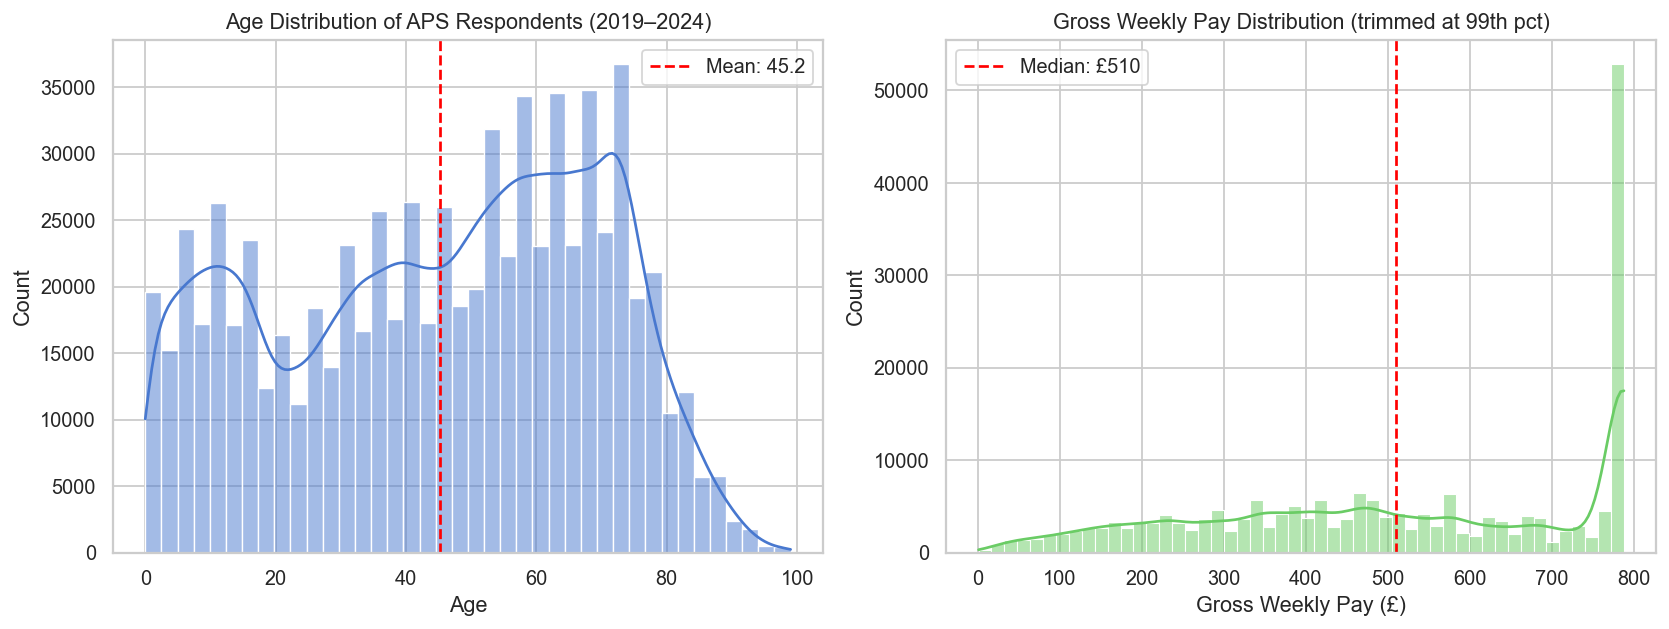

Saved → X:\COMP3008 Report\analysis_outputs\figures\eda1_distributions.png


In [36]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Age distribution ──────────────────────────────────────────────────────────
age = df["AGE"].dropna()
sns.histplot(age, bins=40, kde=True, ax=axes[0], color="#4878CF")
axes[0].set_title("Age Distribution of APS Respondents (2019–2024)")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Count")
axes[0].axvline(age.mean(), color="red", linestyle="--", label=f"Mean: {age.mean():.1f}")
axes[0].legend()

# ── Gross weekly pay distribution (trimmed at 99th percentile to remove outliers)
pay = df["GROSS_WEEKLY_PAY"].dropna()
pay_trimmed = pay[pay <= pay.quantile(0.99)]
sns.histplot(pay_trimmed, bins=50, kde=True, ax=axes[1], color="#6ACC65")
axes[1].set_title("Gross Weekly Pay Distribution (trimmed at 99th pct)")
axes[1].set_xlabel("Gross Weekly Pay (£)")
axes[1].set_ylabel("Count")
axes[1].axvline(pay_trimmed.median(), color="red", linestyle="--",
                label=f"Median: £{pay_trimmed.median():.0f}")
axes[1].legend()

plt.tight_layout()
fig.savefig(FIG_DIR / "eda1_distributions.png", dpi=150)
plt.show()
print(f"Saved → {FIG_DIR / 'eda1_distributions.png'}")

---
## Section 5 — EDA Method 2: Labour Status Time-Series (2019–2024)

**Why this method?**  
A grouped time-series plot shows *how the composition of employment changed  
year-by-year*, making the COVID shock (2020) and recovery (2021–2022) directly  
visible. `ILODEFR` (mapped here as `LABOUR_STATUS`) is the standard ILO  
definition of employment status used by the ONS.

**ILODEFR code meanings (from data dictionary):**  
1 = In employment, 2 = ILO unemployed, 3 = Economically inactive

> **Report link → Application of Methods:** Identify the 2020 dip in employment and  
> discuss how furlough may have affected the ILO classification.

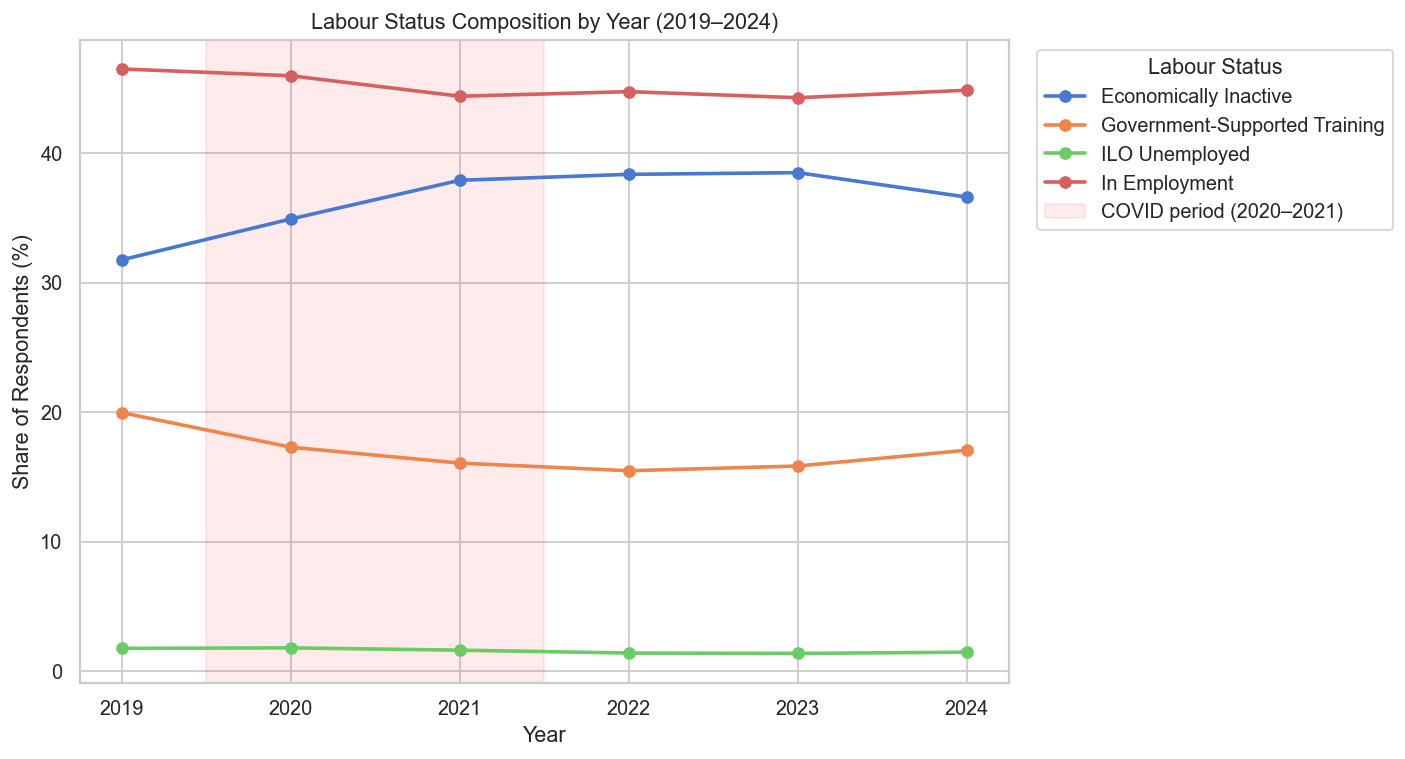

Saved → X:\COMP3008 Report\analysis_outputs\figures\eda2_labour_status_timeseries.png


In [37]:
# Recode numeric codes to readable labels for the chart
STATUS_LABELS = {
    "1": "In Employment",
    "2": "ILO Unemployed",
    "3": "Economically Inactive",
    "4": "Government-Supported Training",
}

ts = df.dropna(subset=["YEAR", "LABOUR_STATUS"]).copy()
ts["YEAR"] = ts["YEAR"].astype(int)
ts["STATUS_LABEL"] = ts["LABOUR_STATUS"].map(STATUS_LABELS).fillna("Other")

# Calculate percentage share of each status per year
grouped = (
    ts.groupby(["YEAR", "STATUS_LABEL"])
    .size()
    .reset_index(name="count")
)
totals = grouped.groupby("YEAR")["count"].transform("sum")
grouped["pct"] = 100 * grouped["count"] / totals

pivot = grouped.pivot(index="YEAR", columns="STATUS_LABEL", values="pct").fillna(0)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 6))
pivot.plot(ax=ax, marker="o", linewidth=2)
ax.axvspan(2019.5, 2021.5, alpha=0.08, color="red", label="COVID period (2020–2021)")
ax.set_title("Labour Status Composition by Year (2019–2024)")
ax.set_xlabel("Year")
ax.set_ylabel("Share of Respondents (%)")
ax.set_xticks(sorted(ts["YEAR"].unique()))
ax.legend(title="Labour Status", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
fig.savefig(FIG_DIR / "eda2_labour_status_timeseries.png", dpi=150)
plt.show()
print(f"Saved → {FIG_DIR / 'eda2_labour_status_timeseries.png'}")

---
## Section 6 — EDA Method 3: Regional Comparison

**Why this method?**  
COVID's economic impact was not uniform across UK regions.  
A regional comparison reveals which Government Office Regions (GORs)  
experienced the greatest employment rate drops and slowest recoveries,  
directly addressing the *regional economies* component of the research question.

> **Report link → Application of Methods:** Compare London vs. the North to discuss  
> structural differences in regional labour markets.

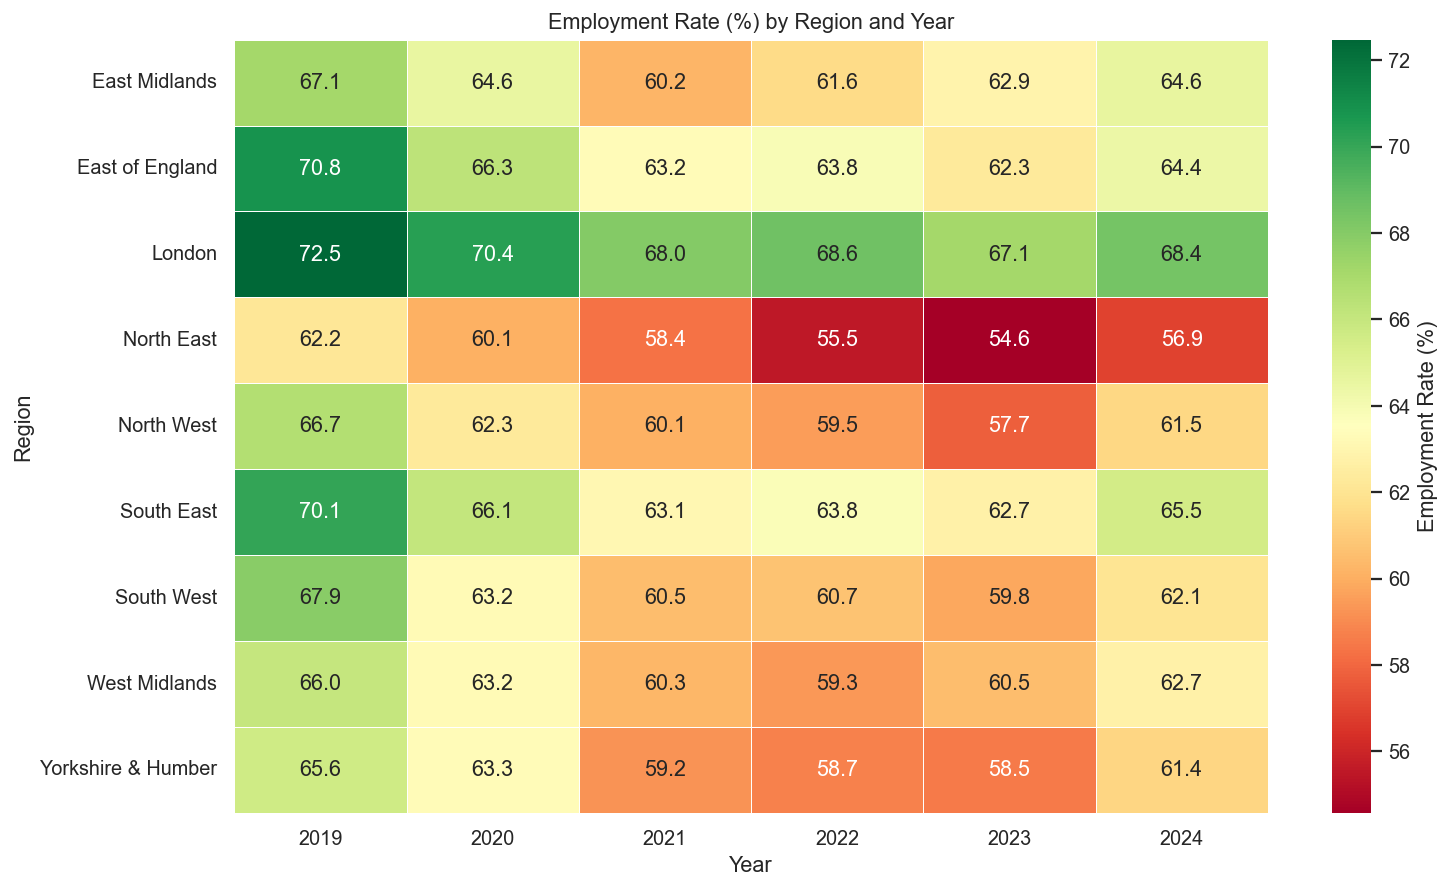

Saved → X:\COMP3008 Report\analysis_outputs\figures\eda3_regional_employment_heatmap.png


In [38]:
# GOR9D region codes (England + Wales + Scotland + NI)
REGION_NAMES = {
    "E12000001": "North East",
    "E12000002": "North West",
    "E12000003": "Yorkshire & Humber",
    "E12000004": "East Midlands",
    "E12000005": "West Midlands",
    "E12000006": "East of England",
    "E12000007": "London",
    "E12000008": "South East",
    "E12000009": "South West",
    "W92000004": "Wales",
    "S92000003": "Scotland",
    "N92000002": "Northern Ireland",
}

reg = df.dropna(subset=["YEAR", "REGION_CODE", "LABOUR_STATUS"]).copy()
reg["YEAR"] = reg["YEAR"].astype(int)
reg["REGION_NAME"] = reg["REGION_CODE"].map(REGION_NAMES)

# Employment rate = proportion of respondents coded as 'In Employment' (ILODEFR = 1)
reg["EMPLOYED"] = reg["LABOUR_STATUS"].isin(["1", "4"]).astype(int)

emp_rate = (
    reg.groupby(["YEAR", "REGION_NAME"])["EMPLOYED"]
    .mean()
    .mul(100)
    .reset_index()
    .rename(columns={"EMPLOYED": "Employment Rate (%)"})
)

# ── Heatmap: regions × years ───────────────────────────────────────────────────
pivot_reg = emp_rate.pivot(index="REGION_NAME", columns="YEAR", values="Employment Rate (%)")

fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(
    pivot_reg,
    annot=True, fmt=".1f",
    cmap="RdYlGn",
    linewidths=0.5,
    ax=ax,
    cbar_kws={"label": "Employment Rate (%)"},
)
ax.set_title("Employment Rate (%) by Region and Year")
ax.set_xlabel("Year")
ax.set_ylabel("Region")
plt.tight_layout()
fig.savefig(FIG_DIR / "eda3_regional_employment_heatmap.png", dpi=150)
plt.show()
print(f"Saved → {FIG_DIR / 'eda3_regional_employment_heatmap.png'}")

---
## Section 7 — EDA Method 4: K-Means Clustering of Worker Profiles

**Why this method?**  
K-Means clustering is an unsupervised method that groups respondents by  
numerical similarity (age, pay, hours). It reveals distinct worker *profiles*  
without assuming categories in advance — useful for checking whether  
COVID affected some clusters more than others.  
PCA is used only to visualise the 5-dimensional cluster space in 2D.

> **Report link → Application of Methods:** Describe each cluster by its centroid  
> values. Discuss whether cluster membership shifted between 2019 and 2021.

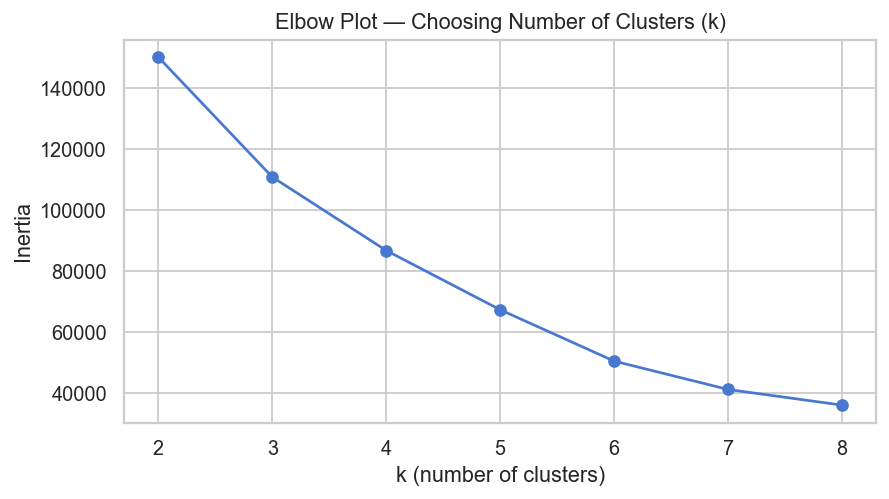

Choose k at the 'elbow' — the point where inertia stops decreasing steeply.


In [39]:
# Features for clustering — only numeric, employment-relevant variables
CLUSTER_FEATURES = ["AGE", "WEIGHT", "GROSS_WEEKLY_PAY", "HOURLY_RATE"]

cluster_work = df[CLUSTER_FEATURES].apply(pd.to_numeric, errors="coerce")

# Use a random sample for speed — 50,000 rows is representative of 750k
sample_n = min(50_000, len(cluster_work))
cluster_sample = cluster_work.sample(n=sample_n, random_state=42)

# ── Elbow method to choose k ───────────────────────────────────────────────────
imputer = SimpleImputer(strategy="median")   # fill missing values with median
scaler  = StandardScaler()                   # standardise so large-scale pay doesn't dominate

X = scaler.fit_transform(imputer.fit_transform(cluster_sample))

inertias = []
K_RANGE  = range(2, 9)
for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(K_RANGE), inertias, marker="o")
ax.set_title("Elbow Plot — Choosing Number of Clusters (k)")
ax.set_xlabel("k (number of clusters)")
ax.set_ylabel("Inertia")
plt.tight_layout()
fig.savefig(FIG_DIR / "eda4a_elbow.png", dpi=150)
plt.show()
print("Choose k at the 'elbow' — the point where inertia stops decreasing steeply.")

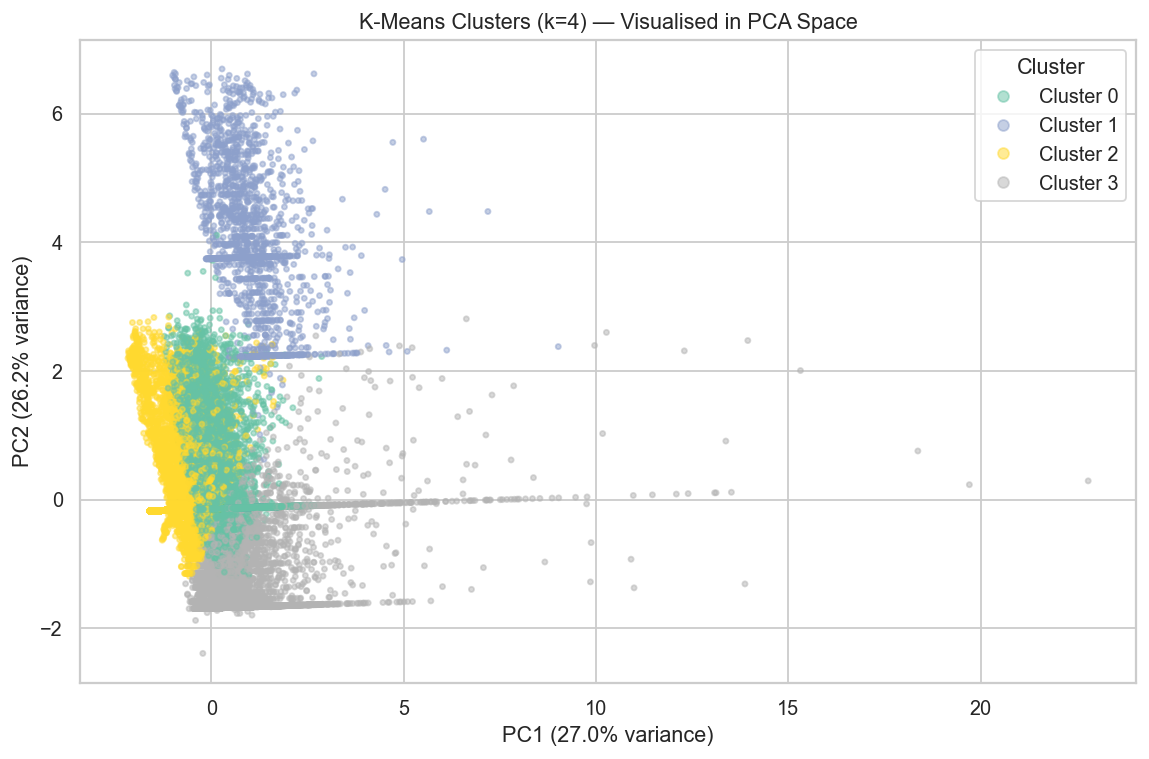


Cluster centroids (original scale):


,AGE,WEIGHT,GROSS_WEEKLY_PAY,HOURLY_RATE
Cluster,,,,
0,64.70,129.09,354.50,11.30
1,45.87,181.70,456.54,79.87
2,18.23,37.21,359.26,10.04
3,42.63,474.82,736.33,17.41


In [40]:
# ── Fit final KMeans with chosen k ────────────────────────────────────────────
# Change K_CHOSEN here if your elbow plot suggests a different value.
K_CHOSEN = 4

kmeans = KMeans(n_clusters=K_CHOSEN, random_state=42, n_init=10)
labels = kmeans.fit_predict(X)

# ── Reduce to 2D with PCA for visualisation only ───────────────────────────────
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X)

fig, ax = plt.subplots(figsize=(9, 6))
scatter = ax.scatter(X_2d[:, 0], X_2d[:, 1], c=labels, cmap="Set2", s=8, alpha=0.5)
ax.set_title(f"K-Means Clusters (k={K_CHOSEN}) — Visualised in PCA Space")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
legend_handles, _ = scatter.legend_elements()
ax.legend(legend_handles, [f"Cluster {i}" for i in range(K_CHOSEN)],
          title="Cluster", loc="best")
plt.tight_layout()
fig.savefig(FIG_DIR / "eda4b_kmeans_pca.png", dpi=150)
plt.show()

# ── Cluster profile summary ───────────────────────────────────────────────────
# Shows the mean of each feature per cluster — helps interpret what each group represents.
cluster_sample_with_labels = cluster_sample.copy()
cluster_sample_with_labels["Cluster"] = labels
print("\nCluster centroids (original scale):")
cluster_sample_with_labels.groupby("Cluster").mean().round(2)

---
## Section 8 — Predictive Method 1: ARIMA Time-Series Forecast

**Why ARIMA?**  
ARIMA models temporal dependence in a univariate sequence. We use the **monthly**  
employment-rate series prepared in Section 3d from APS reference dates (`REFDTE`).

The workflow below:
- validates on 2024 monthly values (trained on 2019–2023)
- compares a small set of **ARIMA-only** (non-seasonal) specifications
- prefers models with good validation error and non-degenerate future shape
- forecasts the next **24 months** (2025–2026) with confidence intervals

**Limitation to discuss in report:**  
This remains a relatively short macro series and may not capture structural breaks.  
Forecasts are indicative rather than causal.

> **Report link → Application of Methods + Results:** Report the selected ARIMA  
> order/trend, 2024 validation MAE, and interpret the 2025–2026 projected path.

Monthly employment series length: 72 months
MONTH
2024-07-01    62.72
2024-08-01    61.83
2024-09-01    62.67
2024-10-01    63.00
2024-11-01    62.37
2024-12-01    62.26

ARIMA candidate leaderboard (top 5):
    order trend      mae  future_std
(1, 0, 0)     c 0.852915    0.085671
(2, 0, 0)     c 1.017269    0.117364
(1, 1, 0)     t 1.979044    0.414565
(2, 1, 0)     t 1.997360    0.413068
(3, 1, 0)     t 2.000079    0.412214

Choosing best non-flat ARIMA model by validation MAE.
Selected ARIMA model: order=(1, 0, 0), trend='c'
Monthly ARIMA MAE on 2024 validation: 0.853 percentage points

Future monthly ARIMA forecast (first 12 months):
2025-01-01    62.29
2025-02-01    62.32
2025-03-01    62.34
2025-04-01    62.36
2025-05-01    62.38
2025-06-01    62.40
2025-07-01    62.42
2025-08-01    62.44
2025-09-01    62.45
2025-10-01    62.46
2025-11-01    62.48
2025-12-01    62.49
Freq: MS


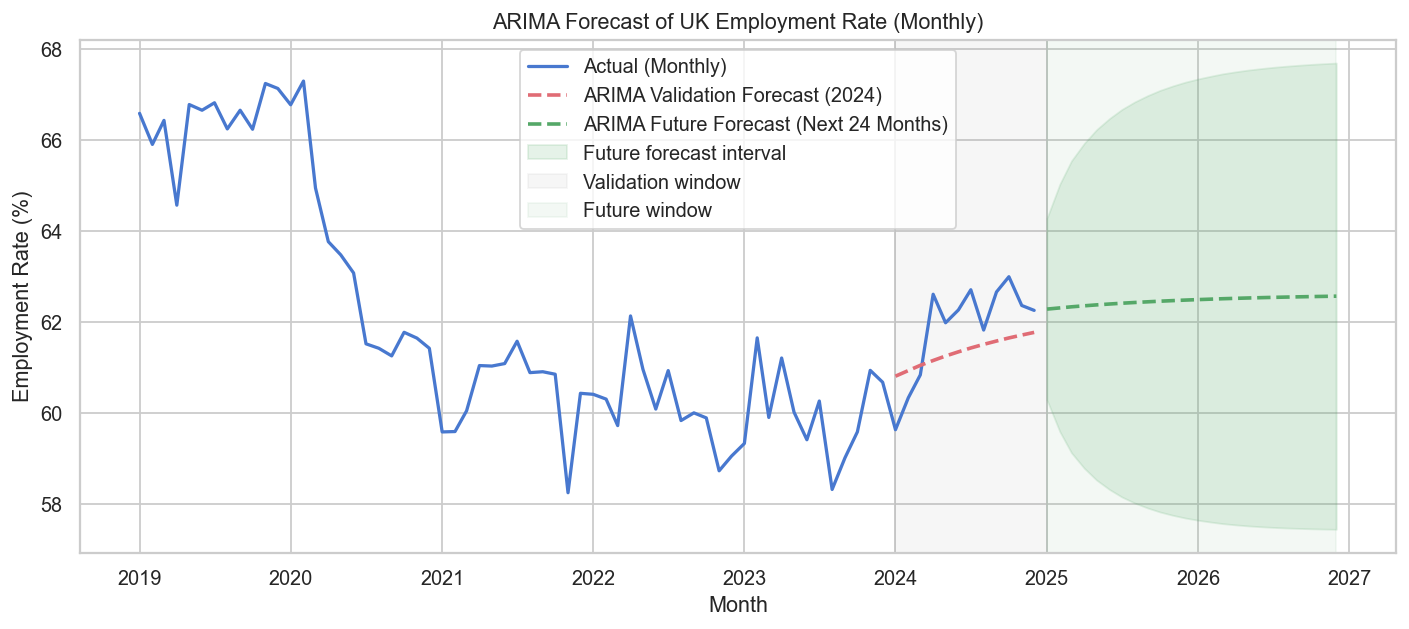

Saved → X:\COMP3008 Report\analysis_outputs\figures\model1_arima_forecast.png


In [41]:
if not ARIMA_AVAILABLE:
    print("Skipping ARIMA — install pmdarima first: pip install pmdarima")
else:
    from statsmodels.tsa.arima.model import ARIMA

    # Use pre-processed time-series inputs from Section 3d.
    if "monthly_emp" not in globals():
        raise RuntimeError("Run Section 3d first: monthly_emp is not prepared.")

    print(f"Monthly employment series length: {len(monthly_emp)} months")
    print(monthly_emp.tail(6).round(2).to_string())

    # Validation split: train through 2023, validate on 2024.
    train_ts = monthly_emp[monthly_emp.index <= "2023-12-31"]
    test_ts = monthly_emp[(monthly_emp.index >= "2024-01-01") & (monthly_emp.index <= "2024-12-31")]

    # Future horizon: next 24 months beyond latest observed month.
    FUTURE_HORIZON = 24
    last_month = monthly_emp.index.max()
    future_months = pd.date_range(last_month + pd.offsets.MonthBegin(1), periods=FUTURE_HORIZON, freq="MS")

    # ARIMA-only candidate set (non-seasonal).
    candidates = [
        {"order": (1, 0, 0), "trend": "c"},
        {"order": (2, 0, 0), "trend": "c"},
        {"order": (1, 1, 0), "trend": "t"},
        {"order": (1, 1, 1), "trend": "t"},
        {"order": (2, 1, 0), "trend": "t"},
        {"order": (2, 1, 1), "trend": "t"},
        {"order": (3, 1, 0), "trend": "t"},
        {"order": (0, 1, 1), "trend": "t"},
    ]

    leaderboard = []
    flat_threshold = 0.02  # std threshold for non-degenerate 24-month forecast

    for spec in candidates:
        try:
            model = ARIMA(train_ts, order=spec["order"], trend=spec["trend"])
            res = model.fit()
            val_pred = pd.Series(res.get_forecast(steps=len(test_ts)).predicted_mean, index=test_ts.index)
            eval_df = pd.concat([test_ts.rename("actual"), val_pred.rename("pred")], axis=1).dropna()
            if len(eval_df) == 0:
                continue
            mae = mean_absolute_error(eval_df["actual"], eval_df["pred"])

            # Fit same spec on full data and assess future profile flatness.
            full_model_tmp = ARIMA(monthly_emp, order=spec["order"], trend=spec["trend"])
            full_res_tmp = full_model_tmp.fit()
            fut_tmp = pd.Series(full_res_tmp.get_forecast(steps=FUTURE_HORIZON).predicted_mean, index=future_months)
            fut_std = float(pd.to_numeric(fut_tmp, errors="coerce").std())

            leaderboard.append({
                "order": spec["order"],
                "trend": spec["trend"],
                "mae": float(mae),
                "future_std": fut_std,
            })
        except Exception:
            continue

    if len(leaderboard) == 0:
        raise RuntimeError("No ARIMA candidate could be fitted successfully.")

    lb = pd.DataFrame(leaderboard).sort_values(["mae", "future_std"], ascending=[True, False]).reset_index(drop=True)
    print("\nARIMA candidate leaderboard (top 5):")
    print(lb.head(5).to_string(index=False))

    non_flat = lb[lb["future_std"] >= flat_threshold]
    if len(non_flat) > 0:
        chosen = non_flat.iloc[0]
        print("\nChoosing best non-flat ARIMA model by validation MAE.")
    else:
        chosen = lb.iloc[0]
        print("\nNo candidate produced strong non-flat dynamics; choosing best MAE ARIMA model.")

    best_order = tuple(chosen["order"])
    best_trend = str(chosen["trend"])

    print(f"Selected ARIMA model: order={best_order}, trend='{best_trend}'")

    # Final validation fit on train period.
    best_val_model = ARIMA(train_ts, order=best_order, trend=best_trend)
    best_val_res = best_val_model.fit()
    test_forecast = pd.Series(best_val_res.get_forecast(steps=len(test_ts)).predicted_mean, index=test_ts.index)
    test_forecast = pd.to_numeric(test_forecast, errors="coerce")
    if test_forecast.isna().any():
        test_forecast = test_forecast.fillna(float(train_ts.dropna().iloc[-1]))

    eval_df = pd.concat([test_ts.rename("actual"), test_forecast.rename("pred")], axis=1).dropna()
    if len(eval_df) == 0:
        arima_mae = float("nan")
        print("Monthly ARIMA MAE on 2024 validation: unavailable (no valid overlap after cleaning)")
    else:
        arima_mae = mean_absolute_error(eval_df["actual"], eval_df["pred"])
        print(f"Monthly ARIMA MAE on 2024 validation: {arima_mae:.3f} percentage points")

    # Refit selected ARIMA model on full monthly data for future forecast.
    best_full_model = ARIMA(monthly_emp, order=best_order, trend=best_trend)
    best_full_res = best_full_model.fit()
    future_obj = best_full_res.get_forecast(steps=FUTURE_HORIZON)
    future_forecast = pd.Series(future_obj.predicted_mean, index=future_months)
    future_ci = future_obj.conf_int()
    future_lower = pd.Series(future_ci.iloc[:, 0].values, index=future_months)
    future_upper = pd.Series(future_ci.iloc[:, 1].values, index=future_months)

    future_forecast = pd.to_numeric(future_forecast, errors="coerce")
    future_lower = pd.to_numeric(future_lower, errors="coerce").fillna(future_forecast)
    future_upper = pd.to_numeric(future_upper, errors="coerce").fillna(future_forecast)
    if future_forecast.isna().any():
        future_forecast = future_forecast.fillna(float(monthly_emp.dropna().iloc[-1]))

    print("\nFuture monthly ARIMA forecast (first 12 months):")
    print(future_forecast.head(12).round(2).to_string())

    # Plot actual + validation forecast + future forecast.
    fig, ax = plt.subplots(figsize=(11, 5))
    ax.plot(monthly_emp.index, monthly_emp.values, label="Actual (Monthly)", color="#4878CF", linewidth=1.8)
    ax.plot(
        test_ts.index,
        test_forecast.values,
        linestyle="--",
        label="ARIMA Validation Forecast (2024)",
        color="#E06C75",
        linewidth=2,
    )
    ax.plot(
        future_months,
        future_forecast.values,
        linestyle="--",
        label="ARIMA Future Forecast (Next 24 Months)",
        color="#55A868",
        linewidth=2,
    )
    ax.fill_between(
        future_months,
        future_lower.values,
        future_upper.values,
        color="#55A868",
        alpha=0.15,
        label="Future forecast interval",
    )

    ax.axvspan(pd.Timestamp("2024-01-01"), pd.Timestamp("2024-12-31"), alpha=0.07, color="grey", label="Validation window")
    ax.axvspan(future_months.min(), future_months.max(), alpha=0.07, color="#55A868", label="Future window")
    ax.set_title("ARIMA Forecast of UK Employment Rate (Monthly)")
    ax.set_xlabel("Month")
    ax.set_ylabel("Employment Rate (%)")
    ax.legend(loc="best")
    plt.tight_layout()
    fig.savefig(FIG_DIR / "model1_arima_forecast.png", dpi=150)
    plt.show()
    print(f"Saved → {FIG_DIR / 'model1_arima_forecast.png'}")

---
## Section 9 — Predictive Method 2: Ridge Regression (Derived Weekly Pay)

**Why Ridge Regression?**  
Ridge is a regularised linear model that is interpretable and serves as a  
strong baseline against which the Random Forest can be compared.  
Here the target is a derived weekly-pay estimate: `HOURLY_RATE × HOURS_WORKED_WEEK`,  
which helps reduce distortion from capping in `GROSS_WEEKLY_PAY`.

**Assumption:** Weekly pay is approximately linearly related to age, qualification,  
region, and hours worked — an assumption the residual plot in Section 10 will test.

> **Report link → Results:** Report R², MAE, and RMSE. Discuss coverage limits from  
missing hourly-rate/hours fields and why this target differs from capped gross weekly pay.

In [42]:
# ── Feature and target selection ───────────────────────────────────────────────
NUM_FEATURES = ["AGE", "YEAR", "WEIGHT", "HOURS_WORKED_WEEK"]
CAT_FEATURES = ["SEX", "HIGHEST_QUAL", "ETHNICITY", "COUNTRY_CODE",
                "REGION_CODE", "LABOUR_STATUS"]

# Use derived weekly pay to reduce capping effects in GRSSWK.
TARGET = "ESTIMATED_WEEKLY_PAY"

model_df = df[NUM_FEATURES + CAT_FEATURES + [TARGET, "GROSS_WEEKLY_PAY"]].copy()
model_df[TARGET] = pd.to_numeric(model_df[TARGET], errors="coerce")
model_df["GROSS_WEEKLY_PAY"] = pd.to_numeric(model_df["GROSS_WEEKLY_PAY"], errors="coerce")

# Require target and core numeric features to be present.
model_df = model_df.dropna(subset=[TARGET, "AGE", "YEAR", "WEIGHT", "HOURS_WORKED_WEEK"])

# Trim top and bottom 1% to reduce influence of extreme products from rate × hours.
lo, hi = model_df[TARGET].quantile([0.01, 0.99])
model_df = model_df[(model_df[TARGET] >= lo) & (model_df[TARGET] <= hi)]

print(f"Target used: {TARGET}")
print(f"Rows available for regression: {len(model_df):,}")
print(f"Target range after trimming: {lo:.2f} – {hi:.2f}")
print(f"Reference observed GROSS_WEEKLY_PAY non-missing in this subset: {model_df['GROSS_WEEKLY_PAY'].notna().sum():,}")

# ── Time-aware train/test split ────────────────────────────────────────────────
# Train on 2019–2023 | Test on 2024 (mimics real forecasting scenario)
train = model_df[model_df["YEAR"] <= 2023]
test  = model_df[model_df["YEAR"] == 2024]

# Fallback: if 2024 has too few rows, use last 20% of data as test
if len(test) < 100:
    split_year = model_df["YEAR"].quantile(0.8)
    train = model_df[model_df["YEAR"] <= split_year]
    test  = model_df[model_df["YEAR"] >  split_year]
    print(f"Fallback split used: train ≤ {split_year}, test > {split_year}")

X_train = train[NUM_FEATURES + CAT_FEATURES]
y_train = train[TARGET]
X_test  = test[NUM_FEATURES + CAT_FEATURES]
y_test  = test[TARGET]

print(f"\nTrain rows: {len(X_train):,} | Test rows: {len(X_test):,}")

Target used: ESTIMATED_WEEKLY_PAY
Rows available for regression: 70,323
Target range after trimming: 40.00 – 4400.00
Reference observed GROSS_WEEKLY_PAY non-missing in this subset: 64,673

Train rows: 60,634 | Test rows: 9,689


In [43]:
# ── Build and fit the Ridge pipeline ──────────────────────────────────────────
def build_reg_pipeline(model) -> Pipeline:
    """Wrap a regressor in an impute → encode → scale → model pipeline."""
    num_pipe = Pipeline([
        ("impute", SimpleImputer(strategy="median")),   # fill numeric NaN with median
        ("scale",  StandardScaler()),                   # z-score normalisation
    ])
    cat_pipe = Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),   # fill categorical NaN
        ("encode", OneHotEncoder(handle_unknown="ignore")),    # dummy encode
    ])
    pre = ColumnTransformer([
        ("num", num_pipe, NUM_FEATURES),
        ("cat", cat_pipe, CAT_FEATURES),
    ])
    return Pipeline([("pre", pre), ("model", model)])

ridge_pipe = build_reg_pipeline(Ridge(alpha=1.0))

# Convert pandas nullable NA to numpy NaN for sklearn compatibility
X_train_clean = X_train.copy()
X_test_clean = X_test.copy()
for col in CAT_FEATURES:
    X_train_clean[col] = X_train_clean[col].astype("object").replace({pd.NA: np.nan})
    X_test_clean[col] = X_test_clean[col].astype("object").replace({pd.NA: np.nan})

ridge_pipe.fit(X_train_clean, y_train)

pred_ridge = ridge_pipe.predict(X_test_clean)

ridge_metrics = {
    "MAE":  mean_absolute_error(y_test, pred_ridge),
    "RMSE": np.sqrt(mean_squared_error(y_test, pred_ridge)),
    "R2":   r2_score(y_test, pred_ridge),
}
print("Ridge Regression metrics:")
for k, v in ridge_metrics.items():
    print(f"  {k}: {v:.4f}")

Ridge Regression metrics:
  MAE: 842.3817
  RMSE: 990.0653
  R2: 0.1881


---
## Section 10 — Predictive Method 3: Random Forest Regressor

**Why Random Forest?**  
Random Forest captures non-linear relationships that Ridge cannot model.  
Comparing the two quantifies how much non-linearity exists in the derived weekly-pay data.

**Suitability note for report:** Random Forest is computationally expensive  
and less interpretable than Ridge, but provides feature importance scores  
that show which factors most predict weekly pay — useful for policy discussion.

> **Report link → Results:** Discuss the feature-importance chart and compare  
> R² and RMSE between Ridge and Random Forest on the derived target.

In [44]:
# Cap training rows for speed — 200k is representative and trains in ~1–2 minutes
MAX_TRAIN = 200_000

# Convert pandas nullable NA to numpy NaN for sklearn compatibility
X_train_rf = X_train.copy()
X_test_rf = X_test.copy()
for col in CAT_FEATURES:
    X_train_rf[col] = X_train_rf[col].astype("object").replace({pd.NA: np.nan})
    X_test_rf[col] = X_test_rf[col].astype("object").replace({pd.NA: np.nan})

if len(X_train_rf) > MAX_TRAIN:
    X_tr_sub = X_train_rf.sample(n=MAX_TRAIN, random_state=42)
    y_tr_sub = y_train.loc[X_tr_sub.index]
else:
    X_tr_sub, y_tr_sub = X_train_rf, y_train

rf_pipe = build_reg_pipeline(
    RandomForestRegressor(
        n_estimators=100,      # 100 trees — good balance of speed vs accuracy
        max_depth=15,          # limit depth to reduce overfitting
        min_samples_leaf=5,    # each leaf must have ≥5 samples
        random_state=42,
        n_jobs=-1,             # use all CPU cores
    )
)
rf_pipe.fit(X_tr_sub, y_tr_sub)

pred_rf = rf_pipe.predict(X_test_rf)

rf_metrics = {
    "MAE":  mean_absolute_error(y_test, pred_rf),
    "RMSE": np.sqrt(mean_squared_error(y_test, pred_rf)),
    "R2":   r2_score(y_test, pred_rf),
}
print("Random Forest metrics:")
for k, v in rf_metrics.items():
    print(f"  {k}: {v:.4f}")

Random Forest metrics:
  MAE: 770.8760
  RMSE: 952.6983
  R2: 0.2482


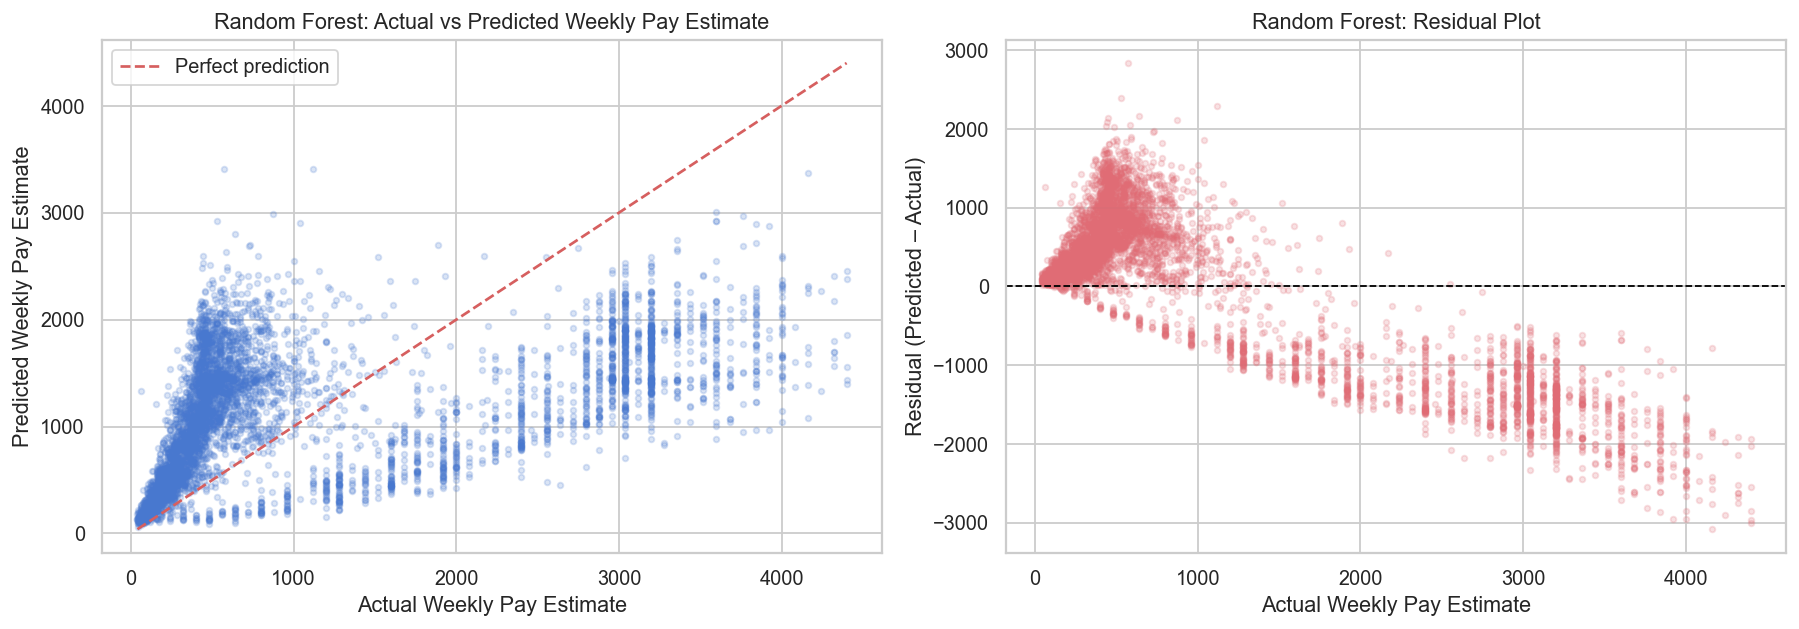

Saved → X:\COMP3008 Report\analysis_outputs\figures\model3_rf_actual_vs_predicted.png


In [45]:
# ── Actual vs Predicted scatter (best model) ───────────────────────────────────
rng = np.random.default_rng(42)
plot_idx = rng.choice(len(y_test), size=min(6000, len(y_test)), replace=False)
y_plot = np.array(y_test.iloc[plot_idx])
p_plot = pred_rf[plot_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter
axes[0].scatter(y_plot, p_plot, alpha=0.2, s=10, color="#4878CF")
lim = [min(y_plot.min(), p_plot.min()), max(y_plot.max(), p_plot.max())]
axes[0].plot(lim, lim, "r--", linewidth=1.5, label="Perfect prediction")
axes[0].set_xlabel("Actual Weekly Pay Estimate")
axes[0].set_ylabel("Predicted Weekly Pay Estimate")
axes[0].set_title("Random Forest: Actual vs Predicted Weekly Pay Estimate")
axes[0].legend()

# Residuals
residuals = p_plot - y_plot
axes[1].scatter(y_plot, residuals, alpha=0.2, s=10, color="#E06C75")
axes[1].axhline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_xlabel("Actual Weekly Pay Estimate")
axes[1].set_ylabel("Residual (Predicted – Actual)")
axes[1].set_title("Random Forest: Residual Plot")

plt.tight_layout()
fig.savefig(FIG_DIR / "model3_rf_actual_vs_predicted.png", dpi=150)
plt.show()
print(f"Saved → {FIG_DIR / 'model3_rf_actual_vs_predicted.png'}")

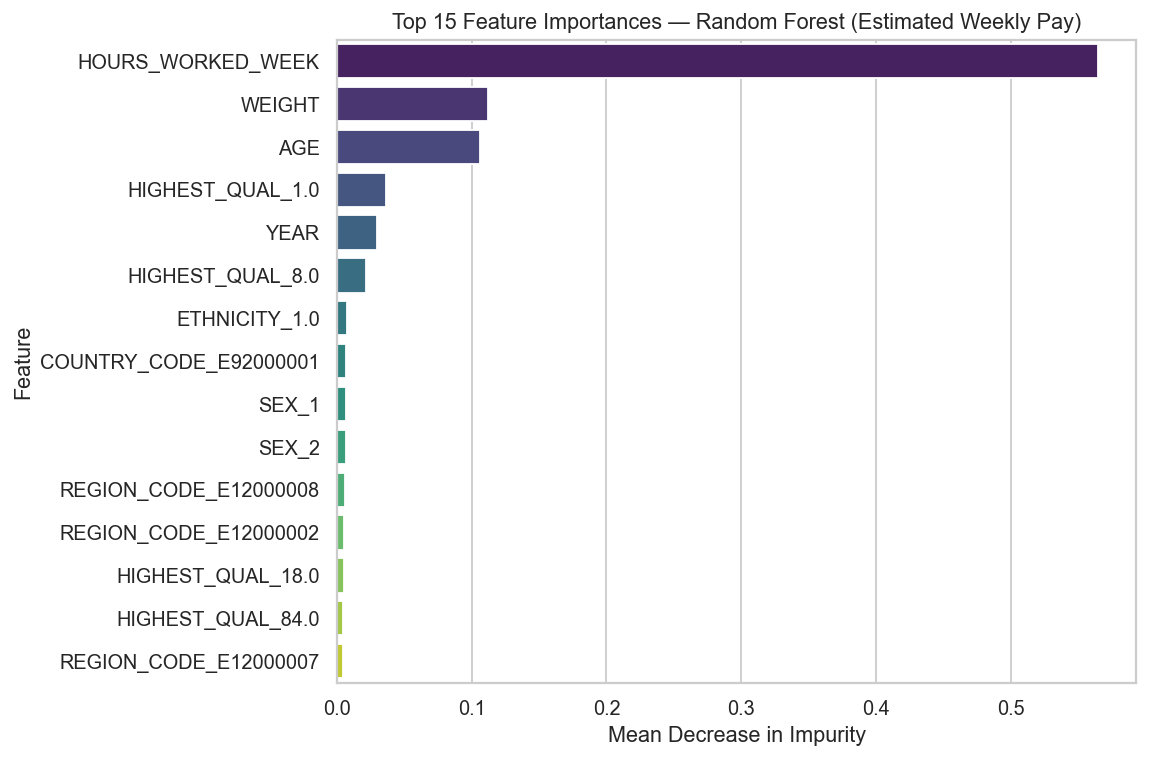

Saved → X:\COMP3008 Report\analysis_outputs\figures\model3_rf_feature_importance.png


In [46]:
# ── Feature importance ────────────────────────────────────────────────────────
# Extract feature names after one-hot encoding
pre_step   = rf_pipe.named_steps["pre"]
cat_names  = pre_step.named_transformers_["cat"]["encode"].get_feature_names_out(CAT_FEATURES)
all_names  = NUM_FEATURES + list(cat_names)

importances = rf_pipe.named_steps["model"].feature_importances_
imp_df = (
    pd.DataFrame({"Feature": all_names, "Importance": importances})
    .sort_values("Importance", ascending=False)
    .head(15)   # show top 15 most important features
)

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(data=imp_df, x="Importance", y="Feature", ax=ax, palette="viridis")
ax.set_title("Top 15 Feature Importances — Random Forest (Estimated Weekly Pay)")
ax.set_xlabel("Mean Decrease in Impurity")
plt.tight_layout()
fig.savefig(FIG_DIR / "model3_rf_feature_importance.png", dpi=150)
plt.show()
print(f"Saved → {FIG_DIR / 'model3_rf_feature_importance.png'}")

---
## Section 11 — Model Comparison & Suitability

This section produces the summary table required by the brief's instruction to  
*'comment on suitability and accuracy of each predictive method'*.

> **Report link → Results:** Paste the table below into your Results section  
> and write one paragraph per model discussing the metrics.

In [47]:
rows = [
    {
        "Model":   "ARIMA",
        "Target":  "Monthly employment rate (%)",
        "MAE":     f"{arima_mae:.3f} pp" if ARIMA_AVAILABLE else "N/A",
        "RMSE":    "N/A (univariate TS)",
        "R²":      "N/A (univariate TS)",
        "Suitability": "Appropriate for monthly trend dynamics; still limited by short macro history and structural-break risk.",
    },
    {
        "Model":   "Ridge Regression",
        "Target":  "Estimated weekly pay (HOURLY_RATE × HOURS_WORKED_WEEK)",
        "MAE":     f"£{ridge_metrics['MAE']:.2f}",
        "RMSE":    f"£{ridge_metrics['RMSE']:.2f}",
        "R²":      f"{ridge_metrics['R2']:.4f}",
        "Suitability": "Interpretable linear baseline; assumes linearity which may not hold.",
    },
    {
        "Model":   "Random Forest",
        "Target":  "Estimated weekly pay (HOURLY_RATE × HOURS_WORKED_WEEK)",
        "MAE":     f"£{rf_metrics['MAE']:.2f}",
        "RMSE":    f"£{rf_metrics['RMSE']:.2f}",
        "R²":      f"{rf_metrics['R2']:.4f}",
        "Suitability": "Captures non-linear patterns; less interpretable, higher compute cost.",
    },
]

comparison_df = pd.DataFrame(rows).set_index("Model")
comparison_df.to_csv(OUT_DIR / "model_comparison.csv")
print("Model Comparison Table:")
comparison_df

Model Comparison Table:


,Target,MAE,RMSE,R²,Suitability
Model,,,,,
ARIMA,Monthly employment rate (%),0.853 pp,N/A (univariate TS),N/A (univariate TS),Appropriate for monthly trend dynamics; still ...
Ridge Regression,Estimated weekly pay (HOURLY_RATE × HOURS_WORK...,£842.38,£990.07,0.1881,Interpretable linear baseline; assumes lineari...
Random Forest,Estimated weekly pay (HOURLY_RATE × HOURS_WORK...,£770.88,£952.70,0.2482,Captures non-linear patterns; less interpretab...


---
## End of Notebook

All figures are saved to `analysis_outputs/figures/`.  
The model comparison table is saved to `analysis_outputs/model_comparison.csv`.

### Quick checklist before submitting
- [ ] Run all cells top-to-bottom (`Kernel → Restart & Run All`) with no errors
- [ ] All figures visible at 100% zoom in the report PDF
- [ ] ARIMA order noted in the report (printed in Section 8)
- [ ] Model comparison table included in Results section
- [ ] AI declaration completed in Appendix A
- [ ] This notebook included as Appendix B